In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("sale.csv")

In [3]:
df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom


In [4]:
df.tail()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
536345,C536548,12/1/2018,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany
536346,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany
536347,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany
536348,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany
536349,C536548,12/1/2018,22767,Triple Photo Frame Cornice,20.45,-2,12472.0,Germany


In [5]:
df.info('TransactionNo')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


In [6]:
df.isnull().sum()

TransactionNo     0
Date              0
ProductNo         0
ProductName       0
Price             0
Quantity          0
CustomerNo       55
Country           0
dtype: int64

In [7]:
df['CustomerNo'].fillna(0,inplace=True)

C:\Users\sagar\AppData\Local\Temp\ipykernel_12584\3432975509.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CustomerNo'].fillna(0,inplace=True)


In [8]:
df.describe()

,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536350.000000
mean,12.662182,9.919347,15226.331634
std,8.490450,216.662300,1723.406925
min,5.130000,-80995.000000,0.000000
25%,10.990000,1.000000,13804.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


In [9]:
df.isnull().sum()

TransactionNo    0
Date             0
ProductNo        0
ProductName      0
Price            0
Quantity         0
CustomerNo       0
Country          0
dtype: int64

In [10]:
df['CustomerNo'].nunique()

4739

In [11]:
df['ProductName'].nunique()

3768

In [12]:
df.groupby("Country")["TransactionNo"].count().sort_values()

Country
Saudi Arabia                10
Bahrain                     17
Czech Republic              28
Brazil                      31
Lithuania                   34
Lebanon                     45
RSA                         57
European Community          58
Greece                      67
United Arab Emirates        67
Malta                      149
Canada                     150
Hong Kong                  153
Poland                     174
Singapore                  215
Israel                     358
Japan                      371
USA                        379
Denmark                    416
Sweden                     417
Unspecified                447
Cyprus                     582
Channel Islands            629
Italy                      661
Finland                    692
Iceland                    787
Austria                    887
Norway                     938
Australia                 1704
Portugal                  1848
Netherlands               2330
Switzerland               2336


In [13]:
df.describe()

,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536350.000000
mean,12.662182,9.919347,15226.331634
std,8.490450,216.662300,1723.406925
min,5.130000,-80995.000000,0.000000
25%,10.990000,1.000000,13804.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


In [14]:
# to calculate revenue first we need to create revenue col and then calculate it
df['Revenue']=df['Price']*df['Quantity']


In [15]:
df.head()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom,127.80
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom,71.64


In [16]:
df.groupby('ProductName')['Revenue'].sum().sort_values(ascending=False).head()

ProductName
Popcorn Holder                        583286.51
World War 2 Gliders Asstd Designs     557170.43
Paper Craft Little Birdie             501359.05
Cream Hanging Heart T-Light Holder    451401.70
Assorted Colour Bird Ornament         420743.70
Name: Revenue, dtype: float64

In [17]:
df.groupby('ProductName')['Quantity'].sum().sort_values(ascending=False).head()

ProductName
Popcorn Holder                       56450
World War 2 Gliders Asstd Designs    53847
Jumbo Bag Red Retrospot              47363
Assorted Colour Bird Ornament        36445
Pack Of 72 Retrospot Cake Cases      36231
Name: Quantity, dtype: int64

In [18]:
df.groupby('ProductName')['Quantity'].sum().sort_values()

ProductName
Travel Card Wallet Dotcomgiftshop     -200
Assorted Tutti Frutti Round Box        -24
White Cherry Lights                     -8
Pink Poodle Hanging Decoration          -7
Vintage Gold Tinsel Reel                -6
                                     ...  
Pack Of 72 Retrospot Cake Cases      36231
Assorted Colour Bird Ornament        36445
Jumbo Bag Red Retrospot              47363
World War 2 Gliders Asstd Designs    53847
Popcorn Holder                       56450
Name: Quantity, Length: 3768, dtype: int64

In [19]:
df.tail()

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue
536345,C536548,12/1/2018,22168,Organiser Wood Antique White,18.96,-2,12472.0,Germany,-37.92
536346,C536548,12/1/2018,21218,Red Spotty Biscuit Tin,14.09,-3,12472.0,Germany,-42.27
536347,C536548,12/1/2018,20957,Porcelain Hanging Bell Small,11.74,-1,12472.0,Germany,-11.74
536348,C536548,12/1/2018,22580,Advent Calendar Gingham Sack,16.35,-4,12472.0,Germany,-65.40
536349,C536548,12/1/2018,22767,Triple Photo Frame Cornice,20.45,-2,12472.0,Germany,-40.90


In [20]:
df.groupby("CustomerNo")["Revenue"].sum().sort_values(ascending=False).head()

CustomerNo
14646.0    2108959.95
18102.0     897137.36
12415.0     895267.24
17450.0     876816.01
14911.0     873037.90
Name: Revenue, dtype: float64

In [21]:
df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(5)

Country
United Kingdom    49994030.17
Netherlands        2147811.39
EIRE               1660645.07
Germany            1350265.40
France             1316880.98
Name: Revenue, dtype: float64

In [22]:
# from date col we would first convert it to date time
#then we would extract month out of it
df['Date']=pd.to_datetime(df['Date'])

In [23]:
df['Month']=df['Date'].dt.month

In [24]:
df.head(3)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue,Month
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64,12
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40,12
2,581475,2019-12-09,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom,138.36,12


In [25]:
df.groupby('Month')['Revenue'].sum().sort_values(ascending=False).head(1)

Month
11    7745257.92
Name: Revenue, dtype: float64

In [26]:
# find the same for year
df['Date']=pd.to_datetime(df['Date'])

In [27]:
df['year']=df['Date'].dt.year

In [28]:
df.groupby('year')['Revenue'].sum().sort_values(ascending=False).head(1)

year
2019    56045876.78
Name: Revenue, dtype: float64

In [29]:
df['Date']=pd.to_datetime(df['Date'])

In [30]:
df['day_name']=df['Date'].dt.day_name

In [31]:
df.groupby('day_name')['Revenue'].sum().sort_values(ascending=False).head(1)

day_name
<bound method PandasDelegate._add_delegate_accessors.<locals>._create_delegator_method.<locals>.f of <pandas.core.indexes.accessors.DatetimeProperties object at 0x00000211A6CA47D0>>    60280024.26
Name: Revenue, dtype: float64

In [32]:
# to find average we needs to do sort of calulation where total revenue is divided bt total orders
total_revenue=df['Revenue'].sum()
total_revenue

np.float64(60280024.26000001)

In [33]:
total_orders=df['TransactionNo'].nunique()
total_orders

23204

In [34]:
avg=total_revenue/total_orders

In [35]:
avg

np.float64(2597.829006205827)

In [36]:
df.head(1)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue,Month,year,day_name
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64,12,2019,<bound method PandasDelegate._add_delegate_acc...


In [37]:
a=df['CustomerNo'].nunique()
a


4739

In [38]:
b=df['Quantity'].sum()
b

np.int64(5320242)

In [39]:
avg_prod=b/a
avg_prod

np.float64(1122.6507702046845)

In [40]:
repeat_customers=df.groupby('CustomerNo')['TransactionNo'].nunique()
repeat_customers=repeat_customers[repeat_customers>1].count()
repeat_customers

np.int64(3320)

In [41]:
customer_quantity = df.groupby("CustomerNo")["Quantity"].sum()

In [42]:
Q1 = customer_quantity.quantile(0.25)
Q3 = customer_quantity.quantile(0.75)

IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

outliers = customer_quantity[customer_quantity > upper_limit]

print(outliers)

CustomerNo
12347.0    3971
12348.0    2332
12357.0    2699
12370.0    2350
12378.0    2529
           ... 
18223.0    2888
18225.0    3206
18226.0    3459
18229.0    2488
18251.0    7824
Name: Quantity, Length: 407, dtype: int64


In [43]:


df["Price_Category"] = pd.cut(
    df["Price"],
    bins=[0, 50, 200, df["Price"].max()],
    labels=["Low Price", "Medium Price", "High Price"]
)

In [44]:
sales = df.groupby("Price_Category")["Quantity"].sum()

print(sales)

Price_Category
Low Price       5319762
Medium Price        402
High Price           78
Name: Quantity, dtype: int64


C:\Users\sagar\AppData\Local\Temp\ipykernel_12584\490608131.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sales = df.groupby("Price_Category")["Quantity"].sum()


<Axes: xlabel='Price_Category'>

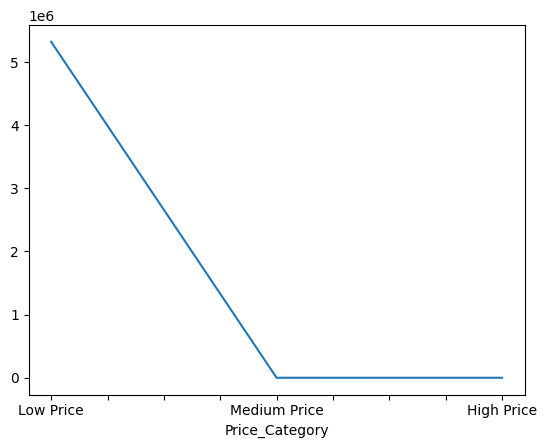

In [45]:
sales.plot()

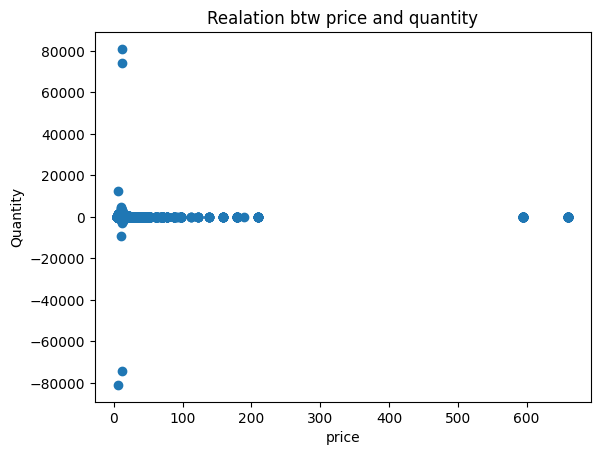

In [46]:
plt.scatter(df['Price'],df['Quantity'])
plt.xlabel("price")
plt.ylabel("Quantity")
plt.title("Realation btw price and quantity")
plt.show()

In [47]:
low_qty = df[df["Quantity"] <= 2]

In [48]:
low_qty_products = low_qty["ProductName"].value_counts()

print(low_qty_products.head(10))

ProductName
Regency Cakestand 3 Tier              1255
Rex Cash+Carry Jumbo Shopper           790
Ivory Kitchen Scales                   624
Set Of 3 Cake Tins Pantry Design       590
Cream Hanging Heart T-Light Holder     588
Jumbo Bag Red Retrospot                535
Recipe Box Pantry Yellow Design        533
Lunch Bag Red Retrospot                505
Red Kitchen Scales                     485
Lunch Bag Suki Design                  482
Name: count, dtype: int64


In [49]:
df.head(2)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country,Revenue,Month,year,day_name,Price_Category
0,581482,2019-12-09,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom,257.64,12,2019,<bound method PandasDelegate._add_delegate_acc...,Low Price
1,581475,2019-12-09,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom,383.40,12,2019,<bound method PandasDelegate._add_delegate_acc...,Low Price
